In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
train_data = pd.read_csv('digit-recognizer/train.csv')
test_data = pd.read_csv('digit-recognizer/test.csv')

In [4]:
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_data = np.array(train_data)
test_data = np.array(test_data)

In [6]:
m, n = train_data.shape
print(m, n)

42000 785


In [7]:
np.random.shuffle(train_data)
data_dev = train_data[0:1000].T
Y_dev = data_dev[0].astype(int)
X_dev = data_dev[1:n] / 255

data_train = train_data[1000:m].T
Y_train = data_train[0].astype(int)
X_train = data_train[1:n] / 255

In [37]:
def init_params():
    W1 = np.random.randn(256, 784)* np.sqrt(2/784) # He initialization for ReLU activation
    b1 = np.random.randn(256, 1)* 0.01 
    W2 = np.random.randn(128, 256)* np.sqrt(2/256)
    b2 = np.random.randn(128, 1)* 0.01
    W3 = np.random.randn(10, 128)* np.sqrt(1/128) # Xavier initialization for softmax activation
    b3 = np.random.randn(10, 1)* 0.01
    return W1, b1, W2, b2, W3, b3

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=0, keepdims=True)

def forward_prop(X, W1, b1, W2, b2, W3, b3):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def deriv_ReLU(Z):
    return Z > 0

def backward_prop(Z1, A1, Z2, A2, Z3, A3, W2, W3, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)

    # Backprop from output layer (layer 3)
    dZ3 = A3 - one_hot_Y
    dW3 = (1 / m) * dZ3.dot(A2.T)
    db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True)

    # Backprop to hidden layer 2
    dA2 = W3.T.dot(dZ3)
    dZ2 = dA2 * deriv_ReLU(Z2)
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Backprop to hidden layer 1
    dA1 = W2.T.dot(dZ2)
    dZ1 = dA1 * deriv_ReLU(Z1)
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3
    return W1, b1, W2, b2, W3, b3

In [62]:
def get_predictions(A3):
    return np.argmax(A3, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, learning_rate1, learning_rate2):
    W1, b1, W2, b2, W3, b3 = init_params()
    switched = False
    switch_iteration = -1
    
    for i in range(iterations):
        Z1, A1, Z2, A2, Z3, A3 = forward_prop(X, W1, b1, W2, b2, W3, b3)
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2, Z3, A3, W2, W3, X, Y)
        
        # Determine which learning rate to use
        current_lr = learning_rate1 if not switched else learning_rate2
        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, current_lr)
      
        if i % 10 == 0:
            accuracy = get_accuracy(get_predictions(A3), Y)
            print("Iteration: ", i)
            print("Accuracy: ", accuracy)
            
            # Switch learning rate if accuracy exceeds 0.95 and haven't switched yet
            if accuracy > 0.95 and not switched:
                switched = True
                switch_iteration = i
                print(f"*** Switched to learning rate {learning_rate2} at iteration {i} ***")    

    return W1, b1, W2, b2, W3, b3

In [63]:
W1, b1, W2, b2, W3, b3 = gradient_descent(X_train, Y_train, iterations=5000, learning_rate1=1, learning_rate2=0.25)

Iteration:  0
Accuracy:  0.13531707317073172
Iteration:  10
Accuracy:  0.19495121951219513
Iteration:  20
Accuracy:  0.44226829268292683
Iteration:  30
Accuracy:  0.2575609756097561
Iteration:  40
Accuracy:  0.28604878048780485
Iteration:  50
Accuracy:  0.405609756097561
Iteration:  60
Accuracy:  0.5145609756097561
Iteration:  70
Accuracy:  0.4163170731707317
Iteration:  80
Accuracy:  0.28585365853658534
Iteration:  90
Accuracy:  0.31158536585365854
Iteration:  100
Accuracy:  0.44253658536585366
Iteration:  110
Accuracy:  0.4083170731707317
Iteration:  120
Accuracy:  0.5255365853658537
Iteration:  130
Accuracy:  0.5240243902439025
Iteration:  140
Accuracy:  0.49053658536585365
Iteration:  150
Accuracy:  0.7933414634146342
Iteration:  160
Accuracy:  0.8052439024390244
Iteration:  170
Accuracy:  0.6851463414634147
Iteration:  180
Accuracy:  0.8472439024390244
Iteration:  190
Accuracy:  0.8775609756097561
Iteration:  200
Accuracy:  0.8725365853658537
Iteration:  210
Accuracy:  0.903780487

In [64]:
# Make predictions on dev data
Z1_dev, A1_dev, Z2_dev, A2_dev, Z3_dev, A3_dev = forward_prop(X_dev, W1, b1, W2, b2, W3, b3)
predictions_dev = get_predictions(A3_dev)
dev_accuracy = get_accuracy(predictions_dev, Y_dev)
print(f"\nDev Data Accuracy: {dev_accuracy:.4f}")


Dev Data Accuracy: 0.9720


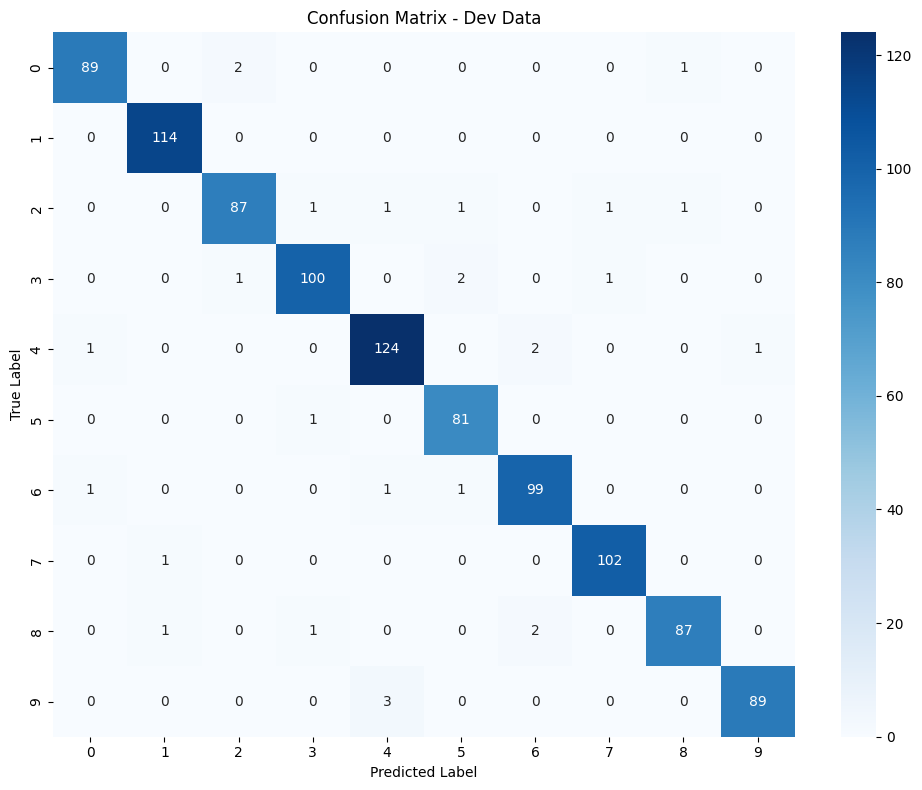

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(Y_dev, predictions_dev)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Dev Data')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Total wrong predictions: 28 out of 1000


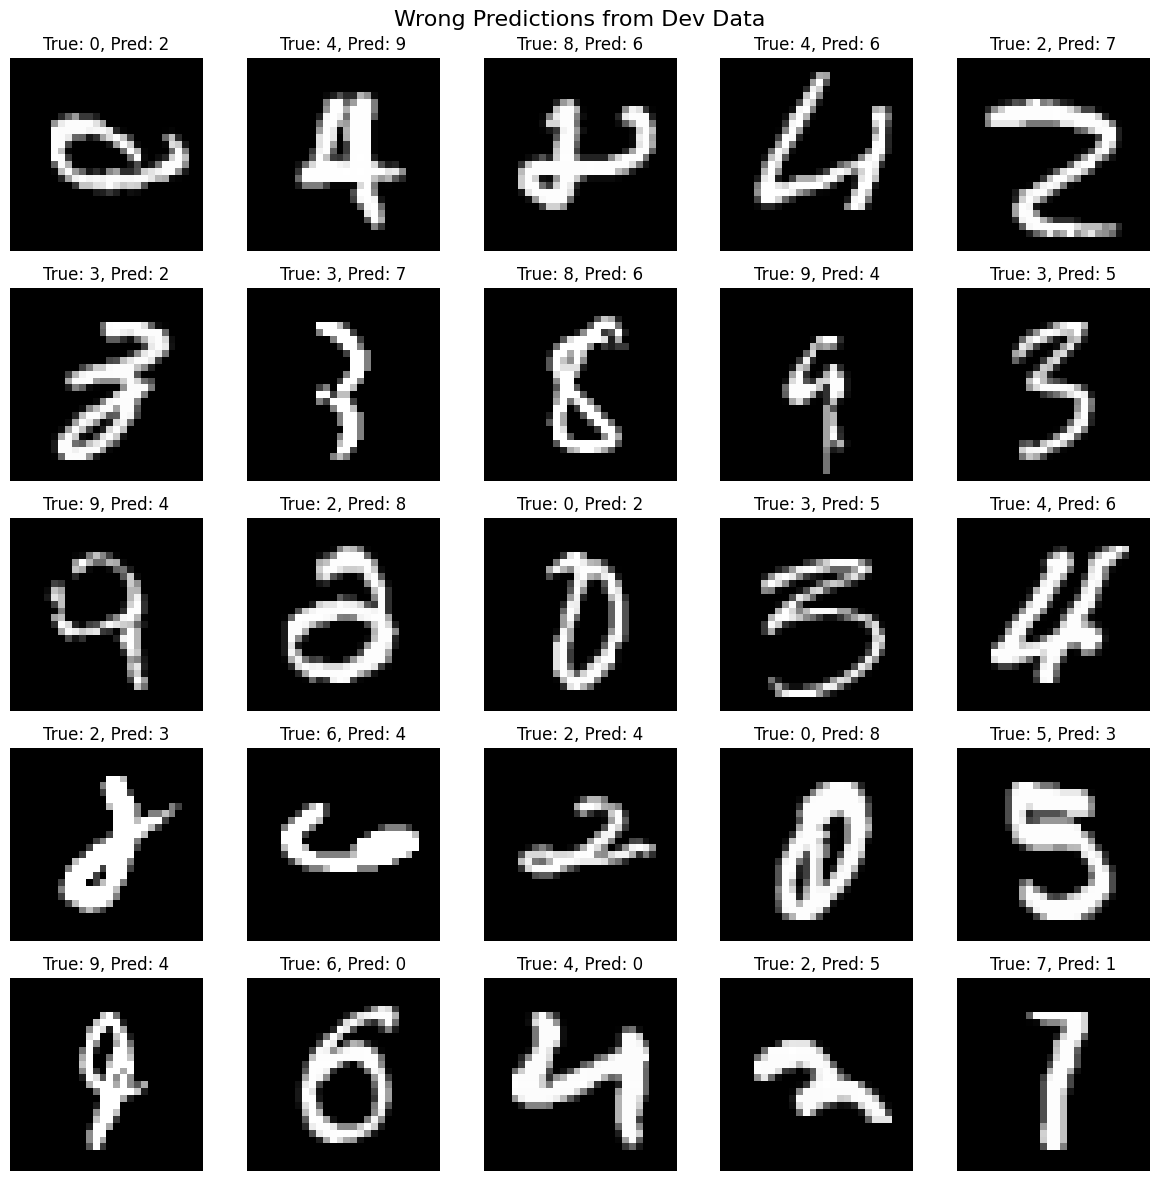

In [66]:
# Display only wrongly predicted digits
wrong_indices = np.where(predictions_dev != Y_dev)[0]
num_wrong = len(wrong_indices)

print(f"Total wrong predictions: {num_wrong} out of {len(Y_dev)}")

# Show first 25 wrong predictions (or fewer if less than 25)
num_to_show = min(25, num_wrong)
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('Wrong Predictions from Dev Data', fontsize=16)

for idx, i in enumerate(wrong_indices[:num_to_show]):
    ax = axes[idx // 5, idx % 5]
    
    # Reshape the pixel data back to 28x28
    image = X_dev[:, i].reshape(28, 28) * 255
    
    # Show the image
    ax.imshow(image, cmap='gray')
    ax.set_title(f'True: {Y_dev[i]}, Pred: {predictions_dev[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [68]:
# Make predictions on test data and create submission
X_test = (test_data.T) / 255

# Forward pass on test data
Z1_test, A1_test, Z2_test, A2_test, Z3_test, A3_test = forward_prop(X_test, W1, b1, W2, b2, W3, b3)
predictions_test = get_predictions(A3_test)

# Create submission dataframe
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(predictions_test) + 1),
    'Label': predictions_test
})

# Save to CSV
submission.to_csv('digit-recognizer/submission.csv', index=False)
print(f"Submission saved! Total predictions: {len(predictions_test)}")
print("\nFirst 10 predictions:")
print(submission.head(10))

Submission saved! Total predictions: 28000

First 10 predictions:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3
